In [1]:
# NLP using Python 
# Combining ML techniques with text and using math and statistics to get text in a format 
# that machine learning algos can understand. 

In [2]:
# Using NLTK toolkit 
# Install via conda 

In [3]:
import nltk 

In [4]:
messages = [line.rstrip() for line in open('smsspamcollection/SMSSpamCollection')]
print(len(messages))

5574


In [7]:
# Collection of text is also called corpus 
# print the first 15 messages 

for message_number, message in enumerate(messages[:16]):
    print(message_number, message)
    print('\n')

0 ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


1 ham	Ok lar... Joking wif u oni...


2 spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


3 ham	U dun say so early hor... U c already then say...


4 ham	Nah I don't think he goes to usf, he lives around here though


5 spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv


6 ham	Even my brother is not like to speak with me. They treat me like aids patent.


7 ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


8 spam	WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

In [8]:
# Using Pandas 

In [9]:
import pandas as pd 

In [10]:
messages = pd.read_csv('smsspamcollection/SMSSpamCollection', sep='\t', names=['label', 'message'])
messages.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [11]:
# Exploratory Data Analysis 

In [12]:
messages.describe() 

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [13]:
# Use groupy by to describe by label 
messages.groupby('label').describe() 

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [14]:
# how long messaging texts are 
messages['length'] = messages['message'].apply(len)
messages.head() 

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [15]:
# Data Visualisations 

In [16]:
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 

<AxesSubplot:ylabel='Frequency'>

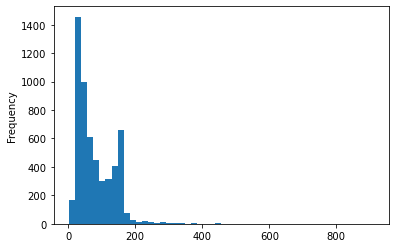

In [17]:
# Histogram of length of messages 
messages['length'].plot(bins=50, kind='hist')

In [18]:
# Statistics 
messages.describe() 

,length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


In [19]:
# Maximum number of characters is 910 

In [20]:
# Getting this message out 

In [21]:
messages[messages['length'] == 910]['message'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

In [23]:
# Text Preprocessing => convert text to numerical before classification algos can work on it. 

In [24]:
# Detour for some tutorials 
import string 

mess = 'Sample message! Notice: it has punctuation.'

# for loop run through the statement above, if characters dont have any punctuations, join all of them 
nopunctuation = [char for char in mess if char not in string.punctuation]

nopunctuation = ''.join(nopunctuation)
print(nopunctuation)

Sample message Notice it has punctuation


In [26]:
# StopWords => commonly used words
nltk.download('stopwords')
from nltk.corpus import stopwords 
stopwords.words('english')[0:10]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessemensah/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

In [27]:
nopunctuation.split() 

['Sample', 'message', 'Notice', 'it', 'has', 'punctuation']

In [28]:
# remove any stopwords 

# run through messages, words in nopunc.split() if words is not in stopwords in english 
cleanedmessage = [word for word in nopunctuation.split() if word.lower() not in stopwords.words('english')]
cleanedmessage

['Sample', 'message', 'Notice', 'punctuation']

In [32]:
# Put it together and apply to the data frame
# 
# function process text  that takes in message 
def process_text(mess):

#  check characters to see if there is not punctuation
     nopunctuation = [char for char in mess if char not in string.punctuation]
# join the characters to form a string 
     nopunctuation = ''.join(nopunctuation)
# finally, remove all the stopwords 
     return [word for word in nopunctuation.split() if word.lower() not in stopwords.words('english')]

In [33]:
messages.head() 

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [34]:
# Tokenise the messages 
messages['message'].head(5).apply(process_text)

0    [Go, jurong, point, crazy, Available, bugis, n...
1                       [Ok, lar, Joking, wif, u, oni]
2    [Free, entry, 2, wkly, comp, win, FA, Cup, fin...
3        [U, dun, say, early, hor, U, c, already, say]
4    [Nah, dont, think, goes, usf, lives, around, t...
Name: message, dtype: object

In [35]:
# Vectorisation 

In [37]:
from sklearn.feature_extraction.text import CountVectorizer 

In [38]:
bow_transformer = CountVectorizer(analyzer=process_text).fit(messages['message'])

# print the total number of vocab words 
print(len(bow_transformer.vocabulary_))

11425


In [42]:
# take on text message and get its back of words count as a vector 
message4 = messages['message'][3]
print(message4)

U dun say so early hor... U c already then say...


In [43]:
# See its vector representation 
bow4 = bow_transformer.transform([message4])
print(bow4)
print(bow4.shape)

  (0, 4068)	2
  (0, 4629)	1
  (0, 5261)	1
  (0, 6204)	1
  (0, 6222)	1
  (0, 7186)	1
  (0, 9554)	2
(1, 11425)


In [47]:
# 7 unique words in message 4 and two of them appear twice and rest appear once 
# Check the once that appear twice 

print(bow_transformer.get_feature_names()[4068])
print(bow_transformer.get_feature_names()[9554])

U
say


In [48]:
# Now use the .transform() on the bag of words transformed object and transform the entire DataFrame of messages 
# Let's go ahead and check out how the bag-of-words counts for the entire SMS corpus is a large, sparse matrix:
messages_bow = bow_transformer.transform(messages['message'])

In [50]:
print('Shape of Sparse Matrix: ', messages_bow.shape) 
print('Amount of Non-Zero occurences: ', messages_bow.nnz)

Shape of Sparse Matrix:  (5572, 11425)
Amount of Non-Zero occurences:  50548


In [ ]:
# Checking the Sparsity 